In [4]:
from dyn_model_class import ModelClass
from dyn_model_estim import *
from helper_functions import *

import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from matplotlib.lines import Line2D
import matplotlib as mpl
import os
from matplotlib.ticker import FuncFormatter, MultipleLocator


%reload_ext autoreload
%autoreload 2

## Load data

In [6]:
### load data
HR_pre_nonpar_u30 = pd.read_excel("data/HR_pre_nonpar_u30.xlsx")
HR_post_nonpar_u30 = pd.read_excel("data/HR_post_nonpar_u30.xlsx")

HR_pre_nonpar_o30 = pd.read_excel("data/HR_pre_nonpar_o30.xlsx")
HR_post_nonpar_o30 = pd.read_excel("data/HR_post_nonpar_o30.xlsx")

HR_pre_par = pd.read_excel("data/HR_pre_par.xlsx")
HR_post_par = pd.read_excel("data/HR_post_par.xlsx")

HR_post_agg = pd.read_excel("data/HR_post_agg.xlsx")
HR_pre_agg = pd.read_excel("data/HR_pre_agg.xlsx")

# take the first 7 weeks of data for imputation
HR_pre_nonpar_u30_impute = HR_pre_nonpar_u30.iloc[:7, :]
HR_pre_nonpar_o30_impute = HR_pre_nonpar_o30.iloc[:7, :]
HR_pre_par_impute = HR_pre_par.iloc[:7, :]
HR_pre_agg_impute = HR_pre_agg.iloc[:7, :]

HR_post_nonpar_u30_impute = HR_post_nonpar_u30.iloc[:7, :]
HR_post_nonpar_o30_impute = HR_post_nonpar_o30.iloc[:7, :]
HR_post_par_impute = HR_post_par.iloc[:7, :]
HR_post_agg_impute = HR_post_agg.iloc[:7, :]

# define population shares
shares_pre = [0.682, 0.119, 0.198]
shares_post = [0.716, 0.119, 0.165]

### Estimate model with log utility
#### Each group (non-parents under 30, non-parents over 30 and parents) estimated seperatly acroos pre- and post with multistart

In [2]:
demo_groups = [("pre1", "post1"), ("pre2", "post2"), ("pre3", "post3")]
group_names = {
    "pre1": "Non-parents u30",
    "pre2": "Non-parents o30",
    "pre3": "Parents"
}

# ── multistart grid
gamma0_list  = [0.5, 1.0, 1.5, 2.0]
delta0_list  = [0.60, 0.73, 0.85]
kappa1_list  = [1.0, 5.0, 10.0, 20.0]
kappa2_list  = [10.0, 50.0, 100.0, 200.0]
shares_list  = [
    np.array([0.35, 0.40, 0.25]),
    np.array([0.20, 0.50, 0.30]),
    np.array([0.50, 0.30, 0.20]),
]

individual_models = {}
theta             = {}

for subgroups in demo_groups:
    pre, post = subgroups
    name      = group_names[pre]
    print(f"\n── Estimating {name} ──────────────────")

    best_fun   = np.inf
    best_model = None
    best_x     = None
    n          = 0

    for gamma0, delta0, k1_0, k2_0, shares0 in itertools.product(
            gamma0_list, delta0_list, kappa1_list, kappa2_list, shares_list):

        if k1_0 >= k2_0:
            continue

        n += 1
        model = ModelClass(
            groups=(pre, post),
            util_type="log", delta_fixed=False)

        model.update_initial_values(
            gamma0       = gamma0,
            delta0       = delta0,
            kappa0       = np.array([k1_0, k2_0, 600.0]),
            type_shares0 = shares0)

        x, fun, success, msg = gmm_estimate_prepost(
            model.par, model.sol, model.data,
            demo_groups=[subgroups])

        if fun < best_fun:
            best_fun   = fun
            best_model = model
            best_x     = x
            print(f"  [{n:>4}] NEW BEST  obj={fun:.4f}  "
                  f"κ={getattr(model.par, pre).kappa}  "
                  f"γ={model.par.gamma:.4f}  δ={model.par.delta:.4f}")

    print(f"\n  Total starts: {n}")
    print(f"  Best obj={best_fun:.4f}")
    print(f"  gamma={best_model.par.gamma:.4f}, delta={best_model.par.delta:.4f}")
    print(f"  kappa={getattr(best_model.par, pre).kappa}")

    individual_models[pre] = best_model
    theta[pre]             = best_x


── Estimating Non-parents u30 ──────────────────
  [   1] NEW BEST  obj=916.2774  κ=[  15.46640357  119.20748038 1672.44802209]  γ=1.2933  δ=0.8335
  [  17] NEW BEST  obj=916.2774  κ=[  15.46654745  119.20824831 1672.45556113]  γ=1.2933  δ=0.8335
  [  21] NEW BEST  obj=916.2774  κ=[  15.46685365  119.21057352 1672.49325335]  γ=1.2933  δ=0.8335
  [  25] NEW BEST  obj=916.2774  κ=[  15.46677687  119.21014583 1672.48983252]  γ=1.2933  δ=0.8335
  [  67] NEW BEST  obj=916.2774  κ=[  15.46683486  119.21062888 1672.49809757]  γ=1.2933  δ=0.8335
  [ 223] NEW BEST  obj=916.2774  κ=[  15.46652178  119.20909781 1672.48171585]  γ=1.2933  δ=0.8335

  Total starts: 504
  Best obj=916.2774
  gamma=1.2933, delta=0.8335
  kappa=[  15.46652178  119.20909781 1672.48171585]

── Estimating Non-parents o30 ──────────────────
  [   1] NEW BEST  obj=508.2060  κ=[ 24.72920562 149.50468881 149.50471468]  γ=0.6843  δ=0.8803
  [   2] NEW BEST  obj=434.4371  κ=[  8.52680958  36.19378332 199.65573873]  γ=0.7053  δ

### Plot model fit

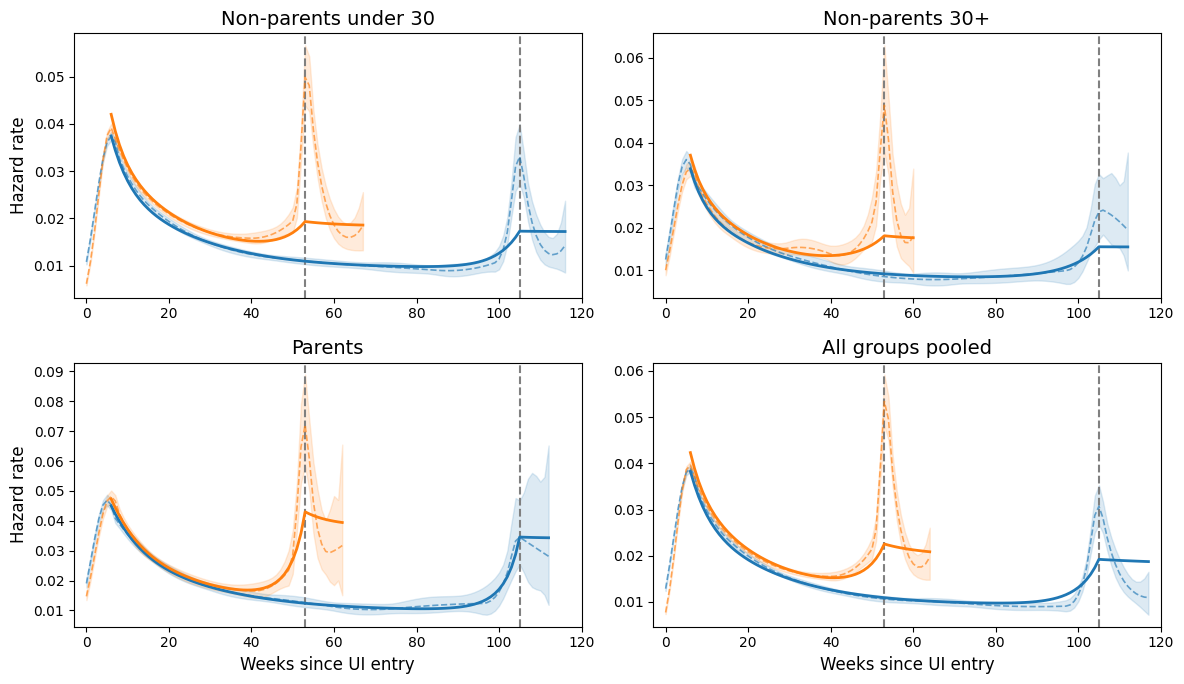

In [7]:
mpl.rcParams.update({
    "font.size":        12,
    "axes.titlesize":   13,
    "axes.labelsize":   12,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
    "legend.fontsize":  10,
})

width    = 2
d_width  = 1.2
alpha    = 0.65
alpha_fill = 0.15
x_pad    = 3

# simulate using individual models
for subgroups in demo_groups:
    pre, post = subgroups
    model = individual_models[pre]
    sim_hr_prepost(model.par, model.sol, [subgroups])

# collect data and solutions from individual models
m1 = individual_models["pre1"]
m2 = individual_models["pre2"]
m3 = individual_models["pre3"]

ms = m1.par.moments_start

x_pre_u   = np.arange(len(m1.data.pre1.moments))
x_post_u  = np.arange(len(m1.data.post1.moments))
x_pre_o   = np.arange(len(m2.data.pre2.moments))
x_post_o  = np.arange(len(m2.data.post2.moments))
x_pre_par = np.arange(len(m3.data.pre3.moments))
x_post_par= np.arange(len(m3.data.post3.moments))

x_pre_u_trim   = np.arange(ms, len(m1.data.pre1.moments))
x_post_u_trim  = np.arange(ms, len(m1.data.post1.moments))
x_pre_o_trim   = np.arange(ms, len(m2.data.pre2.moments))
x_post_o_trim  = np.arange(ms, len(m2.data.post2.moments))
x_pre_par_trim = np.arange(ms, len(m3.data.pre3.moments))
x_post_par_trim= np.arange(ms, len(m3.data.post3.moments))

T_agg_pre  = len(HR_pre_agg)
T_agg_post = len(HR_post_agg)

x_trim_pre = max(len(m1.data.pre1.moments),
                 len(m2.data.pre2.moments),
                 len(m3.data.pre3.moments))

# simulate all pre-reform groups to same length
pre1_moments = simulate_to_length(m1, "pre1", T_agg_pre)
pre2_moments = simulate_to_length(m2, "pre2", T_agg_pre)
pre3_moments = simulate_to_length(m3, "pre3", T_agg_pre)

agg_pre = aggregate_hazard(
    moments_list=[pre1_moments, pre2_moments, pre3_moments],
    shares=shares_post)

T_agg_post = len(HR_post_agg)

post1_moments = simulate_to_length(m1, "post1", T_agg_post)
post2_moments = simulate_to_length(m2, "post2", T_agg_post)
post3_moments = simulate_to_length(m3, "post3", T_agg_post)

agg_post = aggregate_hazard(
    moments_list=[post1_moments, post2_moments, post3_moments],
    shares=shares_post)

t_pre_agg  = np.arange(len(agg_pre))
t_post_agg = np.arange(len(agg_post))

x_pre_agg  = np.arange(len(HR_pre_agg))
x_post_agg = np.arange(len(HR_post_agg))

# ── Plot 2x2 ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey = False)
ax1, ax2  = axes[0, 0], axes[0, 1]
ax3, ax4  = axes[1, 0], axes[1, 1]

# ── Non-parents u30 ───────────────────────────────────────────────────────────
ax1.axvline(x=53,  color="gray", linestyle="--")
ax1.axvline(x=105, color="gray", linestyle="--")
ax1.plot(m1.data.pre1.moments,  label="Empirical HR (pre)",  color="C0",        linestyle="--", linewidth=d_width, alpha=alpha)
ax1.fill_between(x_pre_u,  m1.data.pre1.lower,  m1.data.pre1.upper,  color="C0",        alpha=alpha_fill)
ax1.plot(m1.data.post1.moments, label="Empirical HR (post)", color="tab:orange", linestyle="--", linewidth=d_width, alpha=alpha)
ax1.fill_between(x_post_u, m1.data.post1.lower, m1.data.post1.upper, color="tab:orange", alpha=alpha_fill)
ax1.plot(x_pre_u_trim,  m1.sol.pre1.moments[x_pre_u_trim],   label="Estimated HR (pre)",  color="C0",        linestyle="-", linewidth=width)
ax1.plot(x_post_u_trim, m1.sol.post1.moments[x_post_u_trim], label="Estimated HR (post)", color="tab:orange", linestyle="-", linewidth=width)
ax1.set_title("Non-parents under 30")


# ── Non-parents o30 ───────────────────────────────────────────────────────────
ax2.axvline(x=53,  color="gray", linestyle="--")
ax2.axvline(x=105, color="gray", linestyle="--")
ax2.plot(m2.data.pre2.moments,  label="Empirical HR (pre)",  color="C0",        linestyle="--", linewidth=d_width, alpha=alpha)
ax2.fill_between(x_pre_o,  m2.data.pre2.lower,  m2.data.pre2.upper,  color="C0",        alpha=alpha_fill)
ax2.plot(m2.data.post2.moments, label="Empirical HR (post)", color="tab:orange", linestyle="--", linewidth=d_width, alpha=alpha)
ax2.fill_between(x_post_o, m2.data.post2.lower, m2.data.post2.upper, color="tab:orange", alpha=alpha_fill)
ax2.plot(x_pre_o_trim,  m2.sol.pre2.moments[x_pre_o_trim],   label="Estimated HR (pre)",  color="C0",        linestyle="-", linewidth=width)
ax2.plot(x_post_o_trim, m2.sol.post2.moments[x_post_o_trim], label="Estimated HR (post)", color="tab:orange", linestyle="-", linewidth=width)
ax2.set_title("Non-parents 30+")


# ── Parents ───────────────────────────────────────────────────────────────────
ax3.axvline(x=53,  color="gray", linestyle="--")
ax3.axvline(x=105, color="gray", linestyle="--")
ax3.plot(m3.data.pre3.moments,  label="Empirical HR (pre)",  color="C0",        linestyle="--", linewidth=d_width, alpha=alpha)
ax3.fill_between(x_pre_par,  m3.data.pre3.lower,  m3.data.pre3.upper,  color="C0",        alpha=alpha_fill)
ax3.plot(m3.data.post3.moments, label="Empirical HR (post)", color="tab:orange", linestyle="--", linewidth=d_width, alpha=alpha)
ax3.fill_between(x_post_par, m3.data.post3.lower, m3.data.post3.upper, color="tab:orange", alpha=alpha_fill)
ax3.plot(x_pre_par_trim,  m3.sol.pre3.moments[x_pre_par_trim],   label="Estimated HR (pre)",  color="C0",        linestyle="-", linewidth=width)
ax3.plot(x_post_par_trim, m3.sol.post3.moments[x_post_par_trim], label="Estimated HR (post)", color="tab:orange", linestyle="-", linewidth=width)
ax3.set_title("Parents")


# ── Aggregate ─────────────────────────────────────────────────────────────────
ax4.axvline(x=53,  color="gray", linestyle="--")
ax4.axvline(x=105, color="gray", linestyle="--")
ax4.plot(HR_pre_agg["HR_logit"],  label="Empirical HR (pre)",  color="C0",        linestyle="--", linewidth=d_width, alpha=alpha)
ax4.fill_between(x_pre_agg,  HR_pre_agg["Lower_CI"],  HR_pre_agg["Upper_CI"],  color="C0",        alpha=alpha_fill)
ax4.plot(HR_post_agg["HR_logit"], label="Empirical HR (post)", color="tab:orange", linestyle="--", linewidth=d_width, alpha=alpha)
ax4.fill_between(x_post_agg, HR_post_agg["Lower_CI"], HR_post_agg["Upper_CI"], color="tab:orange", alpha=alpha_fill)
ax4.plot(t_pre_agg[ms:],  agg_pre[ms:],  label="Estimated HR (pre)",  color="C0",        linestyle="-", linewidth=width)
ax4.plot(t_post_agg[ms:], agg_post[ms:], label="Estimated HR (post)", color="tab:orange", linestyle="-", linewidth=width)
ax4.set_title("All groups pooled")
#ax4.legend(fontsize=10)

# ── Shared axis settings ──────────────────────────────────────────────────────
axes[0, 0].set_xlabel("")
axes[0, 1].set_xlabel("")
axes[1, 0].set_xlabel("Weeks since UI entry")
axes[1, 1].set_xlabel("Weeks since UI entry")

axes[0, 0].set_ylabel("Hazard rate", fontsize=12)
axes[1, 0].set_ylabel("Hazard rate", fontsize=12)
axes[0, 1].set_ylabel("")
axes[1, 1].set_ylabel("")

for ax in axes.flat:
    ax.set_xlim(-x_pad, x_trim_pre + x_pad)
    ax.title.set_fontsize(14)
    ax.title.set_fontweight("normal")

plt.tight_layout()
#plt.savefig("model_fit_log.pdf", bbox_inches="tight")
plt.show()

### Compute SE and collect estimated parameters

In [8]:
se_results = {}

for subgroups in demo_groups:
    pre, post = subgroups
    name      = group_names[pre]
    model     = individual_models[pre]
    x         = theta[pre]

    print(f"\n── Standard errors: {name} ──────────────────")

    se, var_theta = par_SE(
        par         = model.par,
        sol         = model.sol,
        data        = model.data,
        demo_groups = [subgroups],
        theta       = x)

    print(f"  len(theta)={len(x)}  len(se)={len(se)}")

    gpar      = getattr(model.par, pre)
    K         = model.par.n_types
    kappas    = gpar.kappa
    shares    = gpar.type_shares
    k3_fixed  = model.par.kappa3_fixed
    nk        = K - 1 if k3_fixed is not False else K  # estimated kappa params
    idx       = 0
    se_orig   = {}

    # ── kappa parameters 
    se_orig["kappa1"] = kappas[0] * se[idx]; idx += 1
    se_orig["kappa2"] = (kappas[1] - kappas[0]) * se[idx]; idx += 1
    if k3_fixed is not False:
        se_orig["kappa3"] = float("nan")  # fixed — no SE
    else:
        se_orig["kappa3"] = (kappas[2] - kappas[1]) * se[idx]; idx += 1

    # ── gamma 
    se_orig["gamma"] = model.par.gamma * se[idx]; idx += 1

    # ── delta 
    if model.par.delta_fixed == False:
        se_orig["delta"] = model.par.delta * (1 - model.par.delta) * se[idx]; idx += 1
    else:
        se_orig["delta"] = float("nan")  # fixed — no SE

    # ── shares via softmax Jacobian 
    z      = np.append(x[idx:idx+K-1], 0.0)
    exp_z  = np.exp(z - np.max(z))
    p      = exp_z / exp_z.sum()
    J_soft = np.diag(p) - np.outer(p, p)
    J_free = J_soft[:, :K-1]
    var_shares_trans = var_theta[idx:idx+K-1, idx:idx+K-1]
    var_shares_orig  = J_free @ var_shares_trans @ J_free.T
    for k in range(K):
        se_orig[f"pi{k+1}"] = np.sqrt(var_shares_orig[k, k])
    idx += K - 1

    # ── beta 
    if model.par.util_type in ("log_shift", "CRRA_shift", "sqrt_shift"):
        gap = gpar.b3 + gpar.beta  # gap = exp(x[idx])
        se_orig["beta"] = gap * se[idx]; idx += 1

    # store SE
    se_results[pre] = {"se_orig": se_orig, "se_trans": se,
                       "var_theta": var_theta}

    # ── print ─────────────────────────────────────────────────────────────────
    print(f"  {'Parameter':10s}  {'Estimate':>10s}  {'SE':>10s}  {'t-stat':>8s}")
    print(f"  {'-'*45}")
    params_est = (
        [(f"kappa{k+1}", kappas[k]) for k in range(K)] +
        [("gamma", model.par.gamma), ("delta", model.par.delta)] +
        [(f"pi{k+1}", shares[k]) for k in range(K)] +
        ([("beta", gpar.beta)] if model.par.util_type in
         ("log_shift", "CRRA_shift", "sqrt_shift") else [])
    )
    for pname, est in params_est:
        se_val = se_orig.get(pname, float("nan"))
        tstat  = est / se_val if (se_val > 0 and np.isfinite(se_val)) else np.nan
        fix    = " (fixed)" if np.isnan(se_val) else ""
        print(f"  {pname:10s}  {est:10.4f}  {se_val:10.4f}  {tstat:8.2f}{fix}")


── Standard errors: Non-parents u30 ──────────────────
  len(theta)=7  len(se)=7
  Parameter     Estimate          SE    t-stat
  ---------------------------------------------
  kappa1         15.4665      5.3847      2.87
  kappa2        119.2091     44.4029      2.68
  kappa3       1672.4817    858.4569      1.95
  gamma           1.2933      0.0896     14.43
  delta           0.8335      0.0468     17.81
  pi1             0.1961      0.0174     11.24
  pi2             0.3037      0.0126     24.16
  pi3             0.5002      0.0168     29.86

── Standard errors: Non-parents o30 ──────────────────
  len(theta)=7  len(se)=7
  Parameter     Estimate          SE    t-stat
  ---------------------------------------------
  kappa1          8.5270      4.4306      1.92
  kappa2         36.1949     16.1472      2.24
  kappa3        199.6654    130.3353      1.53
  gamma           0.7053      0.0992      7.11
  delta           0.8946      0.0460     19.43
  pi1             0.1805      0.045

In [9]:
# ── collect parameters and SE for all groups into one table 
rows = {}

for pre, model in individual_models.items():
    name = group_names[pre]
    par  = model.par
    gpar = getattr(par, pre)
    K    = par.n_types
    se   = se_results[pre]["se_orig"]
    col  = {}

    for k in range(K):
        col[f"$\\kappa_{{{k+1}}}$"]      = f"{gpar.kappa[k]:.4f}"
        col[f"$\\kappa_{{{k+1}}}$ (SE)"] = f"({se[f'kappa{k+1}']:.4f})"

    for k in range(K):
        col[f"$\\pi_{{{k+1}}}$"]      = f"{gpar.type_shares[k]:.4f}"
        col[f"$\\pi_{{{k+1}}}$ (SE)"] = f"({se[f'pi{k+1}']:.4f})"

    if par.util_type in ("CRRA", "CRRA_shift", "linear", "quadratic", "CARA"):
        col["$\\alpha$"]      = f"{gpar.alpha:.4f}"
        col["$\\alpha$ (SE)"] = f"({se.get('alpha', float('nan')):.4f})"

    if par.util_type in ("log_shift", "CRRA_shift", "sqrt_shift"):
        col["$\\beta$"]      = f"{gpar.beta:.4f}"
        col["$\\beta$ (SE)"] = f"({se.get('beta', float('nan')):.4f})"

    col["$\\gamma$"]      = f"{par.gamma:.4f}"
    col["$\\gamma$ (SE)"] = f"({se['gamma']:.4f})"
    col["$\\delta$"]      = f"{par.delta:.4f}"
    col["$\\delta$ (SE)"] = f"({se['delta']:.4f})"

    rows[name] = col

# ── build dataframe
df = pd.DataFrame(rows)

param_order = []
for k in range(K):
    param_order += [f"$\\kappa_{{{k+1}}}$", f"$\\kappa_{{{k+1}}}$ (SE)"]
for k in range(K):
    param_order += [f"$\\pi_{{{k+1}}}$", f"$\\pi_{{{k+1}}}$ (SE)"]
if par.util_type in ("CRRA", "CRRA_shift", "linear", "quadratic", "CARA"):
    param_order += ["$\\alpha$", "$\\alpha$ (SE)"]
if par.util_type in ("log_shift", "CRRA_shift", "sqrt_shift"):
    param_order += ["$\\beta$", "$\\beta$ (SE)"]
param_order += ["$\\gamma$", "$\\gamma$ (SE)", "$\\delta$", "$\\delta$ (SE)"]

df = df.reindex([p for p in param_order if p in df.index])
col_order = [group_names[pre] for pre in ["pre1", "pre2", "pre3"]]
df = df[col_order]

display(df)

# ── export to latex 
latex = df.to_latex(
    escape        = False,
    column_format = "l" + "r" * len(col_order),
    caption       = "Estimated structural parameters",
    label         = "tab:parameters",
    na_rep        = ""
)
print(latex)

,Non-parents u30,Non-parents o30,Parents
$\kappa_{1}$,15.4665,8.5270,5.2789
$\kappa_{1}$ (SE),(5.3847),(4.4306),(1.3431)
$\kappa_{2}$,119.2091,36.1949,9.2991
$\kappa_{2}$ (SE),(44.4029),(16.1472),(1.1755)
$\kappa_{3}$,1672.4817,199.6654,20.5645
$\kappa_{3}$ (SE),(858.4569),(130.3353),(3.6955)
$\pi_{1}$,0.1961,0.1805,0.2411
$\pi_{1}$ (SE),(0.0174),(0.0454),(0.0976)
$\pi_{2}$,0.3037,0.2941,0.3526
$\pi_{2}$ (SE),(0.0126),(0.0207),(0.0734)


\begin{table}
\caption{Estimated structural parameters}
\label{tab:parameters}
\begin{tabular}{lrrr}
\toprule
 & Non-parents u30 & Non-parents o30 & Parents \\
\midrule
$\kappa_{1}$ & 15.4665 & 8.5270 & 5.2789 \\
$\kappa_{1}$ (SE) & (5.3847) & (4.4306) & (1.3431) \\
$\kappa_{2}$ & 119.2091 & 36.1949 & 9.2991 \\
$\kappa_{2}$ (SE) & (44.4029) & (16.1472) & (1.1755) \\
$\kappa_{3}$ & 1672.4817 & 199.6654 & 20.5645 \\
$\kappa_{3}$ (SE) & (858.4569) & (130.3353) & (3.6955) \\
$\pi_{1}$ & 0.1961 & 0.1805 & 0.2411 \\
$\pi_{1}$ (SE) & (0.0174) & (0.0454) & (0.0976) \\
$\pi_{2}$ & 0.3037 & 0.2941 & 0.3526 \\
$\pi_{2}$ (SE) & (0.0126) & (0.0207) & (0.0734) \\
$\pi_{3}$ & 0.5002 & 0.5254 & 0.4064 \\
$\pi_{3}$ (SE) & (0.0168) & (0.0420) & (0.0416) \\
$\gamma$ & 1.2933 & 0.7053 & 0.3999 \\
$\gamma$ (SE) & (0.0896) & (0.0992) & (0.0354) \\
$\delta$ & 0.8335 & 0.8946 & 0.8347 \\
$\delta$ (SE) & (0.0468) & (0.0460) & (0.0331) \\
\bottomrule
\end{tabular}
\end{table}



### Saved model-implied HR (for plotting in seperate notebook)

In [10]:
os.makedirs("output", exist_ok=True)

for subgroups in demo_groups:
    pre, post = subgroups
    model = individual_models[pre]
    ms    = model.par.moments_start

    # ── simulated moments 
    sim_pre = pd.DataFrame({
        "week": np.arange(ms, ms + len(model.sol.__dict__[pre].moments[ms:])),
        "hr":   model.sol.__dict__[pre].moments[ms:],
    })

    sim_post = pd.DataFrame({
        "week": np.arange(ms, ms + len(model.sol.__dict__[post].moments[ms:])),
        "hr":   model.sol.__dict__[post].moments[ms:],
    })

    sim_pre.to_csv( f"output/{pre}_simulated_log.csv",  index=False)
    sim_post.to_csv(f"output/{post}_simulated_log.csv", index=False)

    print(f"Saved {pre}/{post}: sim_pre={len(sim_pre)}, sim_post={len(sim_post)} rows")

# ── aggregate 
ms = m1.par.moments_start

sim_agg_pre_df = pd.DataFrame({
    "week": np.arange(ms, ms + len(agg_pre[ms:])),
    "hr":   agg_pre[ms:],
})

sim_agg_post_df = pd.DataFrame({
    "week": np.arange(ms, ms + len(agg_post[ms:])),
    "hr":   agg_post[ms:],
})

sim_agg_pre_df.to_csv( "output/agg_pre_simulated_log.csv",  index=False)
sim_agg_post_df.to_csv("output/agg_post_simulated_log.csv", index=False)

print("Saved aggregate pre/post simulated.")

Saved pre1/post1: sim_pre=111, sim_post=62 rows
Saved pre2/post2: sim_pre=107, sim_post=55 rows
Saved pre3/post3: sim_pre=107, sim_post=57 rows
Saved aggregate pre/post simulated.


## Validation using Sørensen

In [11]:
# benefit schedule values for input to counterfactuals
pythonpre1_w=8020 
pre1_b1=3522
pre1_b2=3522
pre1_b3=1922*(1-0.33)

pre2_w=7867
pre2_b1=3522
pre2_b2=3522
pre2_b3=2982*(1-0.29)

pre3_w=7732
pre3_b1=4039
pre3_b2=4039
pre3_b3=3595*(1-0.29)

post1_w=8020
post1_b1=3429
post1_b2=2358
post1_b3=1871*(1-0.42)
post1_sa=1871

post2_w=7867
post2_b1=3429
post2_b2=2978
post2_b3=2903*(1-0.35)
post2_sa=2903

post3_w=7732
post3_b1=3932
post3_b2=3932
post3_b3=3543*(1-0.32)
post3_sa=3543

### To validate benefit reduction effect, do counterfactuals on non-parents with post-reform duration (54 weeks) and pre-form vs post-reform benefit levels. 

In [12]:
# ── pre-reform estimated model 
T_common = 60
ms       = m1.par.moments_start

# ── counterfactual 1: non-parents under 30, pre-form benefit levels 
sol_lev_pre_u30, _ = solve_counterfactual(individual_models, "pre1",
    b2=pre1_b2, b3=pre1_b3, T2=54, T3=T_common)

# ── counterfactual 1: non-parents under 30, post-form benefit levels 
sol_lev_post_u30, _ = solve_counterfactual(individual_models, "pre1",
    b2=post1_b2, b3=post1_b3, T2=54, T3=T_common)

# ── counterfactual 1: non-parents over 30, pre-form benefit levels 
sol_lev_pre_o30, _ = solve_counterfactual(individual_models, "pre2",
    b2=pre2_b2, b3=pre2_b3, T2=54, T3=T_common)

# ── counterfactual 1: non-parents over 30, post-form benefit levels 
sol_lev_post_o30, _ = solve_counterfactual(individual_models, "pre2",
    b2=post2_b2, b3=post2_b3, T2=54, T3=T_common)


# ── Make aggegrate for non-parents groups for comparision to Sørensen 
# population shares from my estimation sample
N_u30 = 56_947
N_o30 = 9_397

# aggregate counterfactual hazard rate (pre benefit levels, post duration)
HR_cf_pooled = aggregate_hazard(
    moments_list = [sol_lev_pre_u30.moments, sol_lev_pre_o30.moments],
    shares       = [N_u30, N_o30],
    T            = T_common
)

# aggregate counterfactual hazard rate (pre benefit levels, post duration)
HR_post_pooled = aggregate_hazard(
    moments_list = [sol_lev_post_u30.moments, sol_lev_post_o30.moments],
    shares       = [N_u30, N_o30],
    T            = T_common
)

# ── apply interpolation for first 7 weeks
data_pre_list  = [m1.data.pre1,  m2.data.pre2]
data_post_list = [m1.data.post1, m2.data.post2]

HR_cf_pooled_interp   = interpolate_early_weeks(
    HR_cf_pooled,   data_pre_list, data_post_list, ms, [N_u30, N_o30])

HR_post_pooled_interp = interpolate_early_weeks(
    HR_post_pooled, data_pre_list, data_post_list, ms, [N_u30, N_o30])

# ── treatment effect 
xi_model = HR_post_pooled_interp - HR_cf_pooled_interp

### Load in Sørensens effect data

In [13]:
sor_nonpar_effect = pd.read_csv("data/Sørensen_nonpar_effects.csv")

### Plot Sørensen and own counterfactuals against eachother

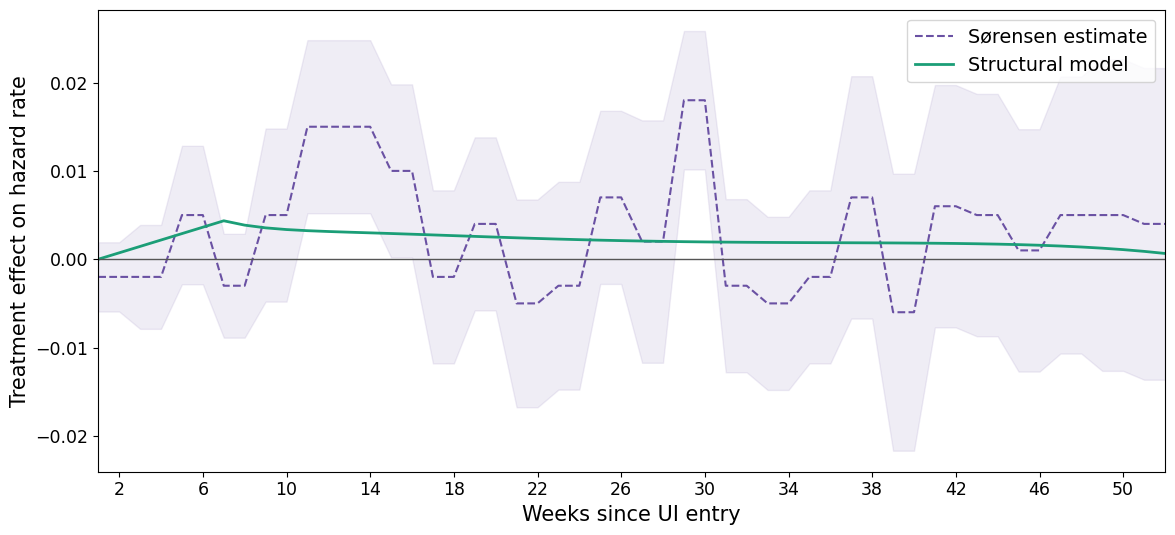

In [14]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Scaled by 1 / 0.8 so fonts match figures inserted at full width
mpl.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 17.5,
    "axes.labelsize": 15,
    "xtick.labelsize": 12.5,
    "ytick.labelsize": 12.5,
    "legend.fontsize": 13.75,
})

sorensen_color = "#6A51A3"
model_color    = "#1B9E77"
band_color     = "#6A51A3"
zero_color     = "#555555"

paper_coefficients = sor_nonpar_effect["coefficient"].values
paper_std_err      = sor_nonpar_effect["std_error"].values

T_plot = 52

paper_arr = np.asarray(paper_coefficients)
se_arr    = np.asarray(paper_std_err)

# Each estimate covers a two-week bin
paper_step = np.repeat(paper_arr, 2)[:T_plot]
se_step    = np.repeat(se_arr, 2)[:T_plot]
weeks_full = np.arange(1, T_plot + 1)

fig, ax = plt.subplots(figsize=(12, 5.6))

# confidence bands
ax.fill_between(
    weeks_full,
    paper_step - 1.96 * se_step,
    paper_step + 1.96 * se_step,
    color=band_color,
    alpha=0.10
)

# Sørensen estimates
ax.plot(
    weeks_full,
    paper_step,
    color=sorensen_color,
    linewidth=1.5,
    linestyle="--",
    label="Sørensen estimate"
)

# Model-implied effect
ax.plot(
    weeks_full,
    xi_model[:T_plot],
    color=model_color,
    linewidth=2,
    label="Structural model"
)

ax.axhline(
    y=0,
    color=zero_color,
    linewidth=1
)

ax.set_xlim(1, T_plot)
ax.set_xticks(np.arange(2, T_plot + 1, 4))

ax.set_xlabel("Weeks since UI entry")
ax.set_ylabel("Treatment effect on hazard rate")

ax.legend(
    loc="best",
    frameon=True
)

plt.tight_layout()
#plt.savefig("sorensen_lev.pdf", bbox_inches="tight")
plt.show()

### Compare treatment effect of potential benefit duration reductions for parents, holding the benefit levels fixed to the post-reform level and change the duration length (so counterfactual with pre duration vs. estimated post model)

In [15]:
# ── pre-reform estimated model 
T_pre = 120
T_post= 60
T_common = 60

ms = m1.par.moments_start

# ── counterfactual: parents, post-reform benefit levels, pre-reform duration 
sol_dur_par_pre, _ = solve_counterfactual(individual_models, "pre3",
    b2=post3_b2, b3=post3_b3, T2=106, T3=T_pre)

# ── counterfactual: parents, post-reform benefit levels, post-reform duration 
sol_dur_par_post, _ = solve_counterfactual(individual_models, "pre3",
    b2=post3_b2, b3=post3_b3, T2=54, T3=T_post)

# ── apply interpolation for first 7 weeks
data_pre_list  = [m3.data.pre3]
data_post_list = [m3.data.post3]

HR_par_post_interp = interpolate_early_weeks(
    sol_dur_par_post.moments[:T_common],
    data_pre_list, data_post_list, ms, [1.0])

HR_par_cf_interp = interpolate_early_weeks(
    sol_dur_par_pre.moments[:T_common],
    data_pre_list, data_post_list, ms, [1.0])

# ── treatment effect 
xi_model_dur = HR_par_post_interp - HR_par_cf_interp

#### Load in Sørensens effect data

In [16]:
sor_par_effect = pd.read_csv("data/Sørensen_par_effects.csv")


### Plot Sørensen and own counterfactuals against eachother

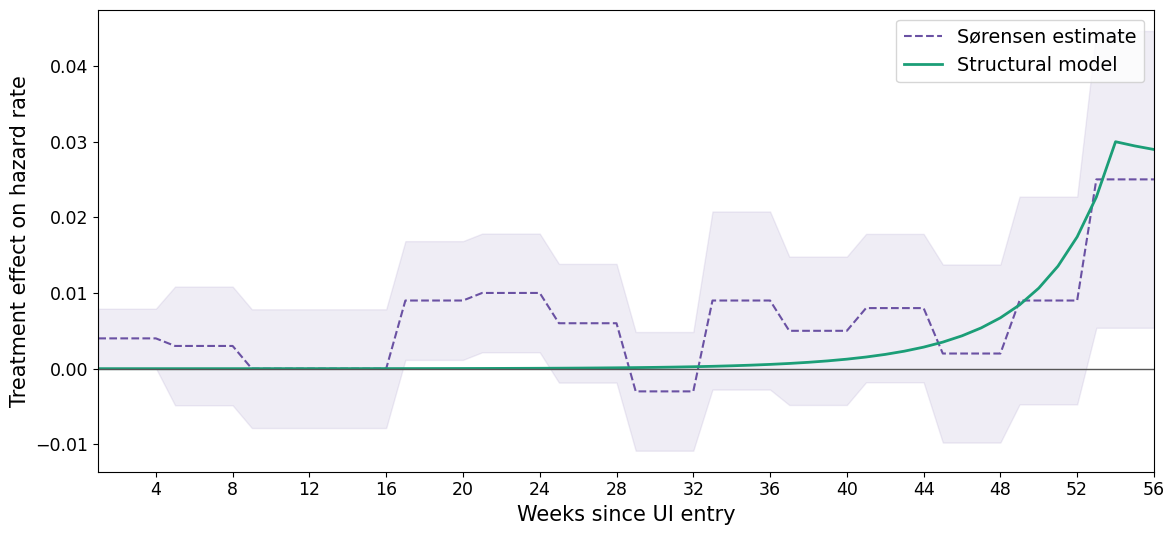

In [17]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Scaled by 1 / 0.8 so fonts match figures inserted at full width
mpl.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 17.5,
    "axes.labelsize": 15,
    "xtick.labelsize": 12.5,
    "ytick.labelsize": 12.5,
    "legend.fontsize": 13.75,
})

sorensen_color = "#6A51A3"
model_color    = "#1B9E77"
band_color     = "#6A51A3"
zero_color     = "#555555"

paper_coefficients = sor_par_effect["estimate"].values
paper_std_err      = sor_par_effect["standard_error"].values

T_plot = 56

paper_arr = np.asarray(paper_coefficients)
se_arr    = np.asarray(paper_std_err)

# Each estimate covers a four-week interval
paper_step = np.repeat(paper_arr, 4)[:T_plot]
se_step    = np.repeat(se_arr, 4)[:T_plot]
weeks_full = np.arange(1, T_plot + 1)

fig, ax = plt.subplots(figsize=(12, 5.6))

# 95% confidence interval
ax.fill_between(
    weeks_full,
    paper_step - 1.96 * se_step,
    paper_step + 1.96 * se_step,
    color=band_color,
    alpha=0.10
)

# Sørensen estimates
ax.plot(
    weeks_full,
    paper_step,
    color=sorensen_color,
    linewidth=1.5,
    linestyle="--",
    label="Sørensen estimate"
)

# Model-implied effect
ax.plot(
    weeks_full,
    xi_model_dur[:T_plot],
    color=model_color,
    linewidth=2,
    label="Structural model"
)

ax.axhline(
    y=0,
    color=zero_color,
    linewidth=1
)

ax.set_xlim(1, T_plot)
ax.set_xticks(np.arange(4, T_plot + 1, 4))

ax.set_xlabel("Weeks since UI entry")
ax.set_ylabel("Treatment effect on hazard rate")

ax.legend(
    loc="best",
    frameon=True
)

plt.tight_layout()
#plt.savefig("sorensen_dur.pdf", bbox_inches="tight")
plt.show()

## Compare to the 2017 reform results from STAR

In [18]:
# ── pre-reform estimated model 
T_common = 156
ms       = m1.par.moments_start
scale_lev = 0.82/0.715

# ── counterfactual 1: non-parents under 30, pre 2023 reform schedule 
sol_23_u30, _ = solve_counterfactual(individual_models, "pre1",
    b2=pre1_b2, b3=pre1_b3, T2=106, T3=T_common)

# ── counterfactual 1: non-parents under 30, pre 2017 reform benefit levels 
sol_17_u30, _ = solve_counterfactual(individual_models, "pre1",
    b2=pre1_b2*scale_lev, b3=pre1_b3, T2=106, T3=T_common)


# ── counterfactual 1: non-parents over 30, pre 2023 reform schedule 
sol_23_o30, _ = solve_counterfactual(individual_models, "pre2",
    b2=pre2_b2, b3=pre2_b3, T2=106, T3=T_common)

# ── counterfactual 1: non-parents over 30, pre 2017 reform benefit levels 
sol_17_o30, _ = solve_counterfactual(individual_models, "pre2",
    b2=pre2_b2*scale_lev, b3=pre2_b3, T2=106, T3=T_common)

# ── Make aggegrate for non-parents groups for comparision to Sørensen 
# population shares from the paper
N_u30 = 54_249
N_o30 = 9_479

# aggregate counterfactual hazard rate (pre benefit levels, post duration)
HR_cf_pooled = aggregate_hazard(
    moments_list = [sol_17_u30.moments, sol_17_o30.moments],
    shares       = [N_u30, N_o30],
    T            = T_common
)

# aggregate counterfactual hazard rate (pre benefit levels, post duration)
HR_post_pooled = aggregate_hazard(
    moments_list = [sol_23_u30.moments, sol_23_o30.moments],
    shares       = [N_u30, N_o30],
    T            = T_common
)

# ── apply interpolation for first 7 weeks
data_pre_list  = [m1.data.pre1,  m2.data.pre2]
data_post_list = [m1.data.post1, m2.data.post2]

HR_cf_pooled_interp   = interpolate_early_weeks(
    HR_cf_pooled,   data_pre_list, data_post_list, ms, [N_u30, N_o30])

HR_post_pooled_interp = interpolate_early_weeks(
    HR_post_pooled, data_pre_list, data_post_list, ms, [N_u30, N_o30])

# ── treatment effect 
xi_model = HR_post_pooled_interp - HR_cf_pooled_interp

### Compute elasticity and full time equivalents

In [19]:
E_2017 = np.sum(survival_function(HR_cf_pooled_interp[:T_common]))
E_2023 = np.sum(survival_function(HR_post_pooled_interp[:T_common]))

pct_change_duration = (E_2023 - E_2017) /E_2017
pct_change_benefit  = (pre1_b2 - pre1_b2*scale_lev) / (pre1_b2*scale_lev)

epsilon = pct_change_duration / pct_change_benefit

FTE = 13589*(E_2023 - E_2017) / 52.14

print(f"Expected duration 2017 levels: {E_2017:.2f} weeks")
print(f"Expected duration 2023 levels: {E_2023:.2f} weeks")
print(f"Net effect:                    {E_2023 - E_2017:.2f} weeks")
print(f"% change in duration:          {pct_change_duration:.4f}")
print(f"% change in benefits:          {pct_change_benefit:.4f}")
print(f"Duration elasticity:           {epsilon:.3f}")
print(f"FTE effect:                    {FTE:.1f} FTEs")

Expected duration 2017 levels: 59.09 weeks
Expected duration 2023 levels: 56.00 weeks
Net effect:                    -3.08 weeks
% change in duration:          -0.0522
% change in benefits:          -0.1280
Duration elasticity:           0.408
FTE effect:                    -803.7 FTEs


# Policy Counterfactuals

### with onset of the postreform schedule shorten and lengthen the UI period

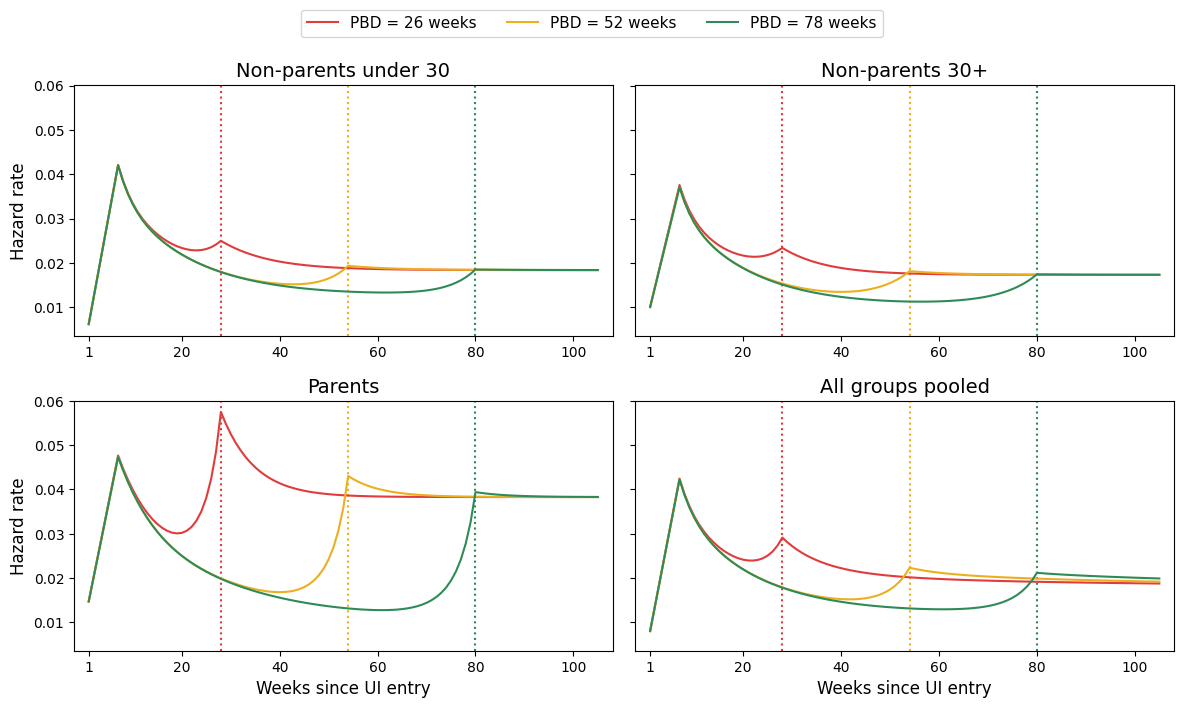

In [20]:
from matplotlib.lines import Line2D
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Same typography as your other full-width plots
mpl.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 11,
})

colors_cf = {
    "s": "#E03C3C",   # clear red — reduction
    "m": "#ECAF1F",   # warm yellow — baseline
    "l": "#2E8B57",   # sea green — increase
}

labels_cf = {
    "s": "PBD = 26 weeks",
    "m": "PBD = 52 weeks",
    "l": "PBD = 78 weeks",
}

# ── counterfactual model 
sol_cf1_s, _ = solve_counterfactual(individual_models, "pre1", w=post1_w, b1=post1_b1, b2=post1_b2, b3=post1_b3, T2=28)
sol_cf2_s, _ = solve_counterfactual(individual_models, "pre2", w=post2_w, b1=post2_b1, b2=post2_b2, b3=post2_b3, T2=28)
sol_cf3_s, _ = solve_counterfactual(individual_models, "pre3", w=post3_w, b1=post3_b1, b2=post3_b2, b3=post3_b3, T2=28)

sol_cf1_m, _ = solve_counterfactual(individual_models, "pre1", w=post1_w, b1=post1_b1, b2=post1_b2, b3=post1_b3, T2=54)
sol_cf2_m, _ = solve_counterfactual(individual_models, "pre2", w=post2_w, b1=post2_b1, b2=post2_b2, b3=post2_b3, T2=54)
sol_cf3_m, _ = solve_counterfactual(individual_models, "pre3", w=post3_w, b1=post3_b1, b2=post3_b2, b3=post3_b3, T2=54)

sol_cf1_l, _ = solve_counterfactual(individual_models, "pre1", w=post1_w, b1=post1_b1, b2=post1_b2, b3=post1_b3, T2=80)
sol_cf2_l, _ = solve_counterfactual(individual_models, "pre2", w=post2_w, b1=post2_b1, b2=post2_b2, b3=post2_b3, T2=80)
sol_cf3_l, _ = solve_counterfactual(individual_models, "pre3", w=post3_w, b1=post3_b1, b2=post3_b2, b3=post3_b3, T2=80)

# ── aggregate hazards 
agg_post = aggregate_hazard(
    moments_list=[individual_models["pre1"].sol.post1.moments,
                  individual_models["pre2"].sol.post2.moments,
                  individual_models["pre3"].sol.post3.moments],
    shares=shares_post)

agg_cf_s = aggregate_hazard(
    moments_list=[sol_cf1_s.moments, sol_cf2_s.moments, sol_cf3_s.moments],
    shares=shares_post)

agg_cf_m = aggregate_hazard(
    moments_list=[sol_cf1_m.moments, sol_cf2_m.moments, sol_cf3_m.moments],
    shares=shares_post)

agg_cf_l = aggregate_hazard(
    moments_list=[sol_cf1_l.moments, sol_cf2_l.moments, sol_cf3_l.moments],
    shares=shares_post)

# ── impute map 
impute_map = {
    "post1": HR_post_nonpar_u30_impute,
    "post2": HR_post_nonpar_o30_impute,
    "post3": HR_post_par_impute,
}

ms = individual_models["pre1"].par.moments_start
m1 = individual_models["pre1"]
m2 = individual_models["pre2"]
m3 = individual_models["pre3"]

# ── interpolation 
cf1_s_interp = interpolate_cf_early(sol_cf1_s.moments, m1.data.post1, ms)
cf1_m_interp = interpolate_cf_early(sol_cf1_m.moments, m1.data.post1, ms)
cf1_l_interp = interpolate_cf_early(sol_cf1_l.moments, m1.data.post1, ms)

cf2_s_interp = interpolate_cf_early(sol_cf2_s.moments, m2.data.post2, ms)
cf2_m_interp = interpolate_cf_early(sol_cf2_m.moments, m2.data.post2, ms)
cf2_l_interp = interpolate_cf_early(sol_cf2_l.moments, m2.data.post2, ms)

cf3_s_interp = interpolate_cf_early(sol_cf3_s.moments, m3.data.post3, ms)
cf3_m_interp = interpolate_cf_early(sol_cf3_m.moments, m3.data.post3, ms)
cf3_l_interp = interpolate_cf_early(sol_cf3_l.moments, m3.data.post3, ms)

# ── truncate 
T_plot = 105

cf1_s_interp = cf1_s_interp[:T_plot]
cf1_m_interp = cf1_m_interp[:T_plot]
cf1_l_interp = cf1_l_interp[:T_plot]

cf2_s_interp = cf2_s_interp[:T_plot]
cf2_m_interp = cf2_m_interp[:T_plot]
cf2_l_interp = cf2_l_interp[:T_plot]

cf3_s_interp = cf3_s_interp[:T_plot]
cf3_m_interp = cf3_m_interp[:T_plot]
cf3_l_interp = cf3_l_interp[:T_plot]

# ── aggregate interpolated 
agg_cf_s_interp = aggregate_hazard([cf1_s_interp, cf2_s_interp, cf3_s_interp], shares=shares_post)
agg_cf_m_interp = aggregate_hazard([cf1_m_interp, cf2_m_interp, cf3_m_interp], shares=shares_post)
agg_cf_l_interp = aggregate_hazard([cf1_l_interp, cf2_l_interp, cf3_l_interp], shares=shares_post)

# ── x axes 
weeks     = np.arange(1, T_plot + 1)
weeks_agg = np.arange(1, len(agg_cf_s_interp) + 1)

x_pad_left, x_pad_right = 3, 3

# ── Plot 2x2 
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=True)

groups_info = [
    (axes[0, 0], cf1_s_interp, cf1_m_interp, cf1_l_interp, "Non-parents under 30"),
    (axes[0, 1], cf2_s_interp, cf2_m_interp, cf2_l_interp, "Non-parents 30+"),
    (axes[1, 0], cf3_s_interp, cf3_m_interp, cf3_l_interp, "Parents"),
]

for ax, cf_s, cf_m, cf_l, title in groups_info:
    ax.plot(weeks, cf_s, label=labels_cf["s"], color=colors_cf["s"], linestyle="-", linewidth=1.5)
    ax.plot(weeks, cf_m, label=labels_cf["m"], color=colors_cf["m"], linestyle="-", linewidth=1.5)
    ax.plot(weeks, cf_l, label=labels_cf["l"], color=colors_cf["l"], linestyle="-", linewidth=1.5)

    ax.axvline(x=28, color=colors_cf["s"], linestyle="dotted", linewidth=1.5, zorder=0)
    ax.axvline(x=54, color=colors_cf["m"], linestyle="dotted", linewidth=1.5, zorder=0)
    ax.axvline(x=80, color=colors_cf["l"], linestyle="dotted", linewidth=1.5, zorder=0)

    ax.set_xlim(1 - x_pad_left, T_plot + x_pad_right)
    ax.set_xticks([1, 20, 40, 60, 80, 100])
    ax.set_title(title, fontweight="normal")
    ax.title.set_fontsize(14)

# ── aggregate panel 
ax_agg = axes[1, 1]
ax_agg.plot(weeks_agg, agg_cf_s_interp, label=labels_cf["s"], color=colors_cf["s"], linestyle="-", linewidth=1.5)
ax_agg.plot(weeks_agg, agg_cf_m_interp, label=labels_cf["m"], color=colors_cf["m"], linestyle="-", linewidth=1.5)
ax_agg.plot(weeks_agg, agg_cf_l_interp, label=labels_cf["l"], color=colors_cf["l"], linestyle="-", linewidth=1.5)

ax_agg.axvline(x=28, color=colors_cf["s"], linestyle="dotted", linewidth=1.5, zorder=0)
ax_agg.axvline(x=54, color=colors_cf["m"], linestyle="dotted", linewidth=1.5, zorder=0)
ax_agg.axvline(x=80, color=colors_cf["l"], linestyle="dotted", linewidth=1.5,zorder=0)

ax_agg.set_xlim(1 - x_pad_left, len(agg_cf_s_interp) + x_pad_right)
ax_agg.set_xticks([1, 20, 40, 60, 80, 100])
ax_agg.set_title("All groups pooled", fontweight="normal")
ax_agg.title.set_fontsize(14)

# ── shared axis settings 
axes[0, 0].set_xlabel("")
axes[0, 1].set_xlabel("")
axes[1, 0].set_xlabel("Weeks since UI entry")
axes[1, 1].set_xlabel("Weeks since UI entry")

axes[0, 0].set_ylabel("Hazard rate")
axes[1, 0].set_ylabel("Hazard rate")
axes[0, 1].set_ylabel("")
axes[1, 1].set_ylabel("")

# ── shared legend 
legend_handles = [
    Line2D([0], [0], color=colors_cf["s"], lw=1.5, label=labels_cf["s"]),
    Line2D([0], [0], color=colors_cf["m"], lw=1.5, label=labels_cf["m"]),
    Line2D([0], [0], color=colors_cf["l"], lw=1.5, label=labels_cf["l"]),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
#plt.savefig("counterfactual_ui_duration_log.pdf", dpi=300, bbox_inches="tight")
plt.show()

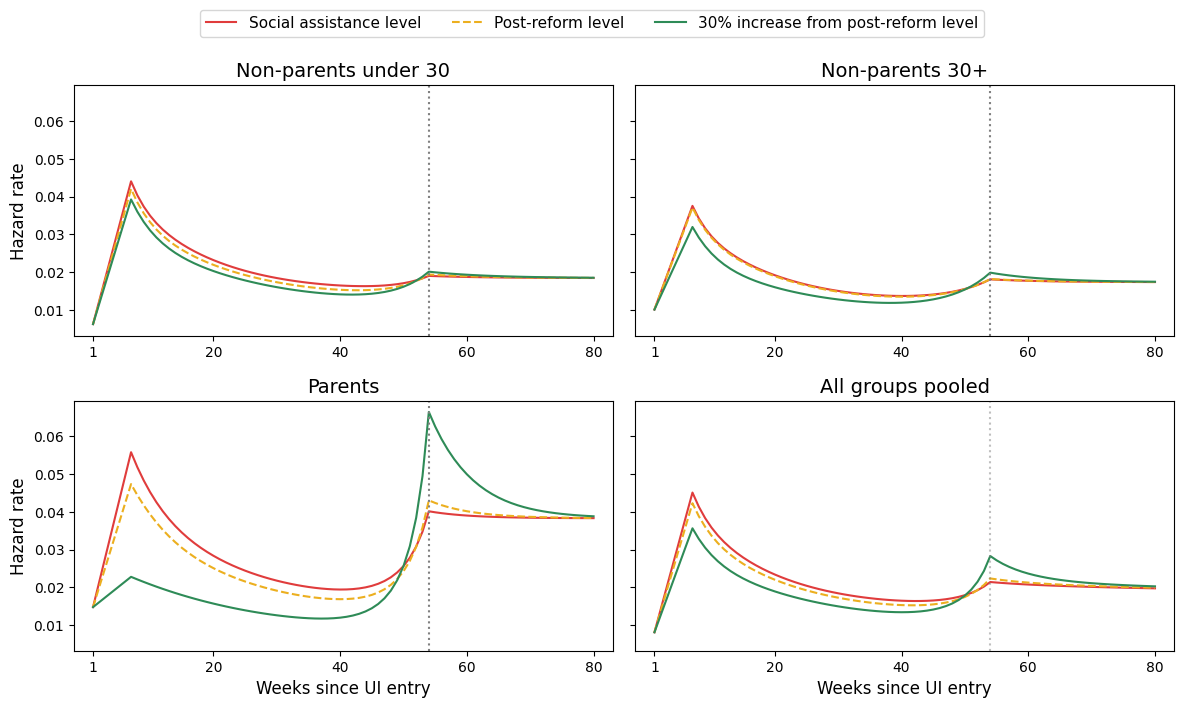

In [21]:
mpl.rcParams.update({
    "font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 11,
})

colors_cf = {"s": "#E03C3C", "m": "#ECAF1F", "l": "#2E8B57"}
labels_cf = {
    "s": "Social assistance level",
    "m": "Post-reform level",
    "l": "30% increase from post-reform level",
}

# ── counterfactual model 
sol_cf1_s, _ = solve_counterfactual(individual_models, "pre1", w=post1_w, b1=post1_b1, b2=post1_sa,       b3=post1_b3, T2=54)
sol_cf2_s, _ = solve_counterfactual(individual_models, "pre2", w=post2_w, b1=post2_b1, b2=post2_sa,       b3=post2_b3, T2=54)
sol_cf3_s, _ = solve_counterfactual(individual_models, "pre3", w=post3_w, b1=post3_b1, b2=post3_sa,       b3=post3_b3, T2=54)
sol_cf1_m, _ = solve_counterfactual(individual_models, "pre1", w=post1_w, b1=post1_b1, b2=post1_b2,       b3=post1_b3, T2=54)
sol_cf2_m, _ = solve_counterfactual(individual_models, "pre2", w=post2_w, b1=post2_b1, b2=post2_b2,       b3=post2_b3, T2=54)
sol_cf3_m, _ = solve_counterfactual(individual_models, "pre3", w=post3_w, b1=post3_b1, b2=post3_b2,       b3=post3_b3, T2=54)
sol_cf1_l, _ = solve_counterfactual(individual_models, "pre1", w=post1_w, b1=post1_b1, b2=post1_b2*1.3,  b3=post1_b3, T2=54)
sol_cf2_l, _ = solve_counterfactual(individual_models, "pre2", w=post2_w, b1=post2_b1, b2=post2_b2*1.3,  b3=post2_b3, T2=54)
sol_cf3_l, _ = solve_counterfactual(individual_models, "pre3", w=post3_w, b1=post3_b1, b2=post3_b2*1.3,  b3=post3_b3, T2=54)

# ── aggregate hazards 
m1, m2, m3 = individual_models["pre1"], individual_models["pre2"], individual_models["pre3"]
ms = m1.par.moments_start

agg_post  = aggregate_hazard([m1.sol.post1.moments, m2.sol.post2.moments, m3.sol.post3.moments], shares=shares_post)
agg_cf_s  = aggregate_hazard([sol_cf1_s.moments, sol_cf2_s.moments, sol_cf3_s.moments], shares=shares_post)
agg_cf_m  = aggregate_hazard([sol_cf1_m.moments, sol_cf2_m.moments, sol_cf3_m.moments], shares=shares_post)
agg_cf_l  = aggregate_hazard([sol_cf1_l.moments, sol_cf2_l.moments, sol_cf3_l.moments], shares=shares_post)

impute_map = {"post1": HR_post_nonpar_u30_impute, "post2": HR_post_nonpar_o30_impute, "post3": HR_post_par_impute}

# ── interpolation + truncation 
T_plot = 80

cf1_s_interp = interpolate_cf_early(sol_cf1_s.moments, m1.data.post1, ms)[:T_plot]
cf1_m_interp = interpolate_cf_early(sol_cf1_m.moments, m1.data.post1, ms)[:T_plot]
cf1_l_interp = interpolate_cf_early(sol_cf1_l.moments, m1.data.post1, ms)[:T_plot]
cf2_s_interp = interpolate_cf_early(sol_cf2_s.moments, m2.data.post2, ms)[:T_plot]
cf2_m_interp = interpolate_cf_early(sol_cf2_m.moments, m2.data.post2, ms)[:T_plot]
cf2_l_interp = interpolate_cf_early(sol_cf2_l.moments, m2.data.post2, ms)[:T_plot]
cf3_s_interp = interpolate_cf_early(sol_cf3_s.moments, m3.data.post3, ms)[:T_plot]
cf3_m_interp = interpolate_cf_early(sol_cf3_m.moments, m3.data.post3, ms)[:T_plot]
cf3_l_interp = interpolate_cf_early(sol_cf3_l.moments, m3.data.post3, ms)[:T_plot]

# ── aggregate interpolated 
agg_cf_s_interp = aggregate_hazard([cf1_s_interp, cf2_s_interp, cf3_s_interp], shares=shares_post)
agg_cf_m_interp = aggregate_hazard([cf1_m_interp, cf2_m_interp, cf3_m_interp], shares=shares_post)
agg_cf_l_interp = aggregate_hazard([cf1_l_interp, cf2_l_interp, cf3_l_interp], shares=shares_post)

# ── x axes 
weeks     = np.arange(1, T_plot + 1)
weeks_agg = np.arange(1, len(agg_cf_s_interp) + 1)
x_pad_left, x_pad_right = 3, 3

# ── Plot 2x2 
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=True)

groups_info = [
    (axes[0, 0], m1, "pre1", "post1", cf1_s_interp, cf1_m_interp, cf1_l_interp, "Non-parents under 30"),
    (axes[0, 1], m2, "pre2", "post2", cf2_s_interp, cf2_m_interp, cf2_l_interp, "Non-parents 30+"),
    (axes[1, 0], m3, "pre3", "post3", cf3_s_interp, cf3_m_interp, cf3_l_interp, "Parents"),
]

for ax, m, pre, post, cf_s, cf_m, cf_l, title in groups_info:
    ax.plot(weeks, cf_s, label=labels_cf["s"], color=colors_cf["s"], linestyle="-",  linewidth=1.5)
    ax.plot(weeks, cf_m, label=labels_cf["m"], color=colors_cf["m"], linestyle="--", linewidth=1.5)
    ax.plot(weeks, cf_l, label=labels_cf["l"], color=colors_cf["l"], linestyle="-",  linewidth=1.5)
    ax.axvline(x=54, color="grey", linestyle=":", linewidth=1.5)
    ax.set_xlim(1 - x_pad_left, T_plot + x_pad_right)
    ax.set_xticks([1, 20, 40, 60, 80])
    ax.set_title(title, fontsize=14, fontweight="normal")

# ── aggregate panel 
ax_agg = axes[1, 1]
ax_agg.plot(weeks_agg, agg_cf_s_interp, label=labels_cf["s"], color=colors_cf["s"], linestyle="-",  linewidth=1.5)
ax_agg.plot(weeks_agg, agg_cf_m_interp, label=labels_cf["m"], color=colors_cf["m"], linestyle="--", linewidth=1.5)
ax_agg.plot(weeks_agg, agg_cf_l_interp, label=labels_cf["l"], color=colors_cf["l"], linestyle="-",  linewidth=1.5)
ax_agg.axvline(x=54, color="grey", linestyle=":", alpha=0.5)
ax_agg.set_xlim(1 - x_pad_left, len(agg_cf_s_interp) + x_pad_right)
ax_agg.set_xticks([1, 20, 40, 60, 80])
ax_agg.set_title("All groups pooled", fontsize=14, fontweight="normal")

# ── shared axis labels 
axes[0, 0].set_xlabel(""); axes[0, 1].set_xlabel("")
axes[1, 0].set_xlabel("Weeks since UI entry"); axes[1, 1].set_xlabel("Weeks since UI entry")
axes[0, 0].set_ylabel("Hazard rate"); axes[1, 0].set_ylabel("Hazard rate")
axes[0, 1].set_ylabel(""); axes[1, 1].set_ylabel("")

# ── shared legend 
legend_handles = [
    Line2D([0], [0], color=colors_cf["s"], lw=1.5, linestyle="-",  label=labels_cf["s"]),
    Line2D([0], [0], color=colors_cf["m"], lw=1.5, linestyle="--", label=labels_cf["m"]),
    Line2D([0], [0], color=colors_cf["l"], lw=1.5, linestyle="-",  label=labels_cf["l"]),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=3, frameon=True, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout(rect=[0, 0, 1, 0.96])
#plt.savefig("counterfactual_ui_level_log.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Expected unemployment duration
#### Make counterfactuals with plotted unemployment duration and value function as function of duration and benefit level

In [22]:
T2_range = np.arange(26, 211, 2)

results = {
    "pre1": {"E": []},
    "pre2": {"E": []},
    "pre3": {"E": []},
    "agg":  {"E": []},
}

post_exhaustion_window = 50

for T2 in T2_range:
    T3   = T2 + post_exhaustion_window
    sols = {}

    for grp, ind_model, params in [
        ("pre1", individual_models, dict(w=post1_w, b1=post1_b1, b2=post1_b2, b3=post1_b3)),
        ("pre2", individual_models, dict(w=post2_w, b1=post2_b1, b2=post2_b2, b3=post2_b3)),
        ("pre3", individual_models, dict(w=post3_w, b1=post3_b1, b2=post3_b2, b3=post3_b3)),
    ]:
        sol, _ = solve_counterfactual(ind_model, grp, T2=T2, T3=T3, **params)
        results[grp]["E"].append(np.sum(survival_function(sol.moments[:T3])))
        sols[grp] = sol

    agg_hr = aggregate_hazard(
        moments_list=[sols["pre1"].moments, sols["pre2"].moments, sols["pre3"].moments],
        shares=shares_post, T=T3)
    results["agg"]["E"].append(np.sum(survival_function(agg_hr[:T3])))

for group in results:
    results[group]["E"] = np.array(results[group]["E"])

results_T2 = results

In [26]:
# ── SA floor thresholds ───────────────────────────────────────────────────────
sa_floor_b_s = {
    "pre1": post1_sa / post1_b2,
    "pre2": post2_sa / post2_b2,
    "pre3": post3_sa / post3_b2,
}

b_scale = np.arange(0., 1.5, 0.01)

results = {
    "pre1": {"E": []},
    "pre2": {"E": []},
    "pre3": {"E": []},
    "agg":  {"E": []},
}

post_exhaustion_window = 50

for b_s in b_scale:
    T2   = 54
    T3   = T2 + post_exhaustion_window
    sols = {}

    for grp, ind_model, params in [
        ("pre1", individual_models, dict(w=post1_w, b1=post1_b1, b2=post1_b2*b_s, b3=post1_b3)),
        ("pre2", individual_models, dict(w=post2_w, b1=post2_b1, b2=post2_b2*b_s, b3=post2_b3)),
        ("pre3", individual_models, dict(w=post3_w, b1=post3_b1, b2=post3_b2*b_s, b3=post3_b3)),
    ]:
        sol, _ = solve_counterfactual(ind_model, grp, T2=T2, T3=T3, **params)
        results[grp]["E"].append(np.sum(survival_function(sol.moments[:T3])))
        sols[grp] = sol

    agg_hr = aggregate_hazard(
        moments_list=[sols["pre1"].moments, sols["pre2"].moments, sols["pre3"].moments],
        shares=shares_post, T=T3)
    results["agg"]["E"].append(np.sum(survival_function(agg_hr[:T3])))

for group in results:
    results[group]["E"] = np.array(results[group]["E"])

results_b = results

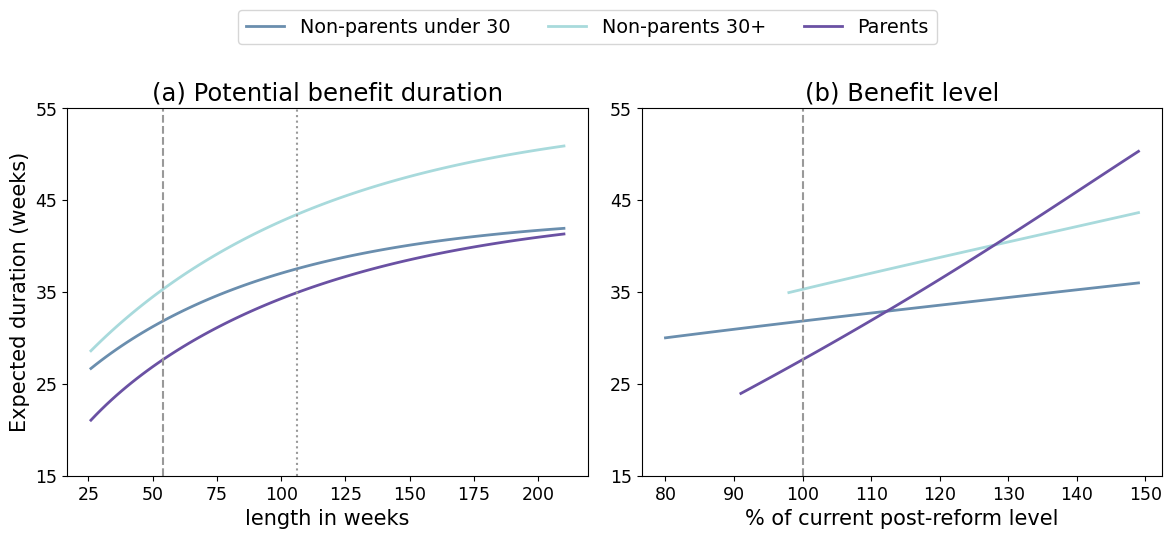

In [ ]:

# Scaled for insertion at width=0.8\linewidth
mpl.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 17.5,
    "axes.labelsize": 15,
    "xtick.labelsize": 12.5,
    "ytick.labelsize": 12.5,
    "legend.fontsize": 13.75,
})


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.3), sharey=False)

colors = {"pre1": "#6A8EAE", "pre2": "#A8DADC", "pre3": "#6A51A3"}
labels = {"pre1": "Non-parents under 30", "pre2": "Non-parents 30+", "pre3": "Parents"}
reference_color, reference_alpha, reference_width = "0.6", 1, 1.5

# ── left panel: potential benefit duration ────────────────────────────────────
for group in ["pre1", "pre2", "pre3"]:
    ax1.plot(T2_range, results_T2[group]["E"], color=colors[group], linewidth=2, label=labels[group])

ax1.axvline(54,  color=reference_color, linestyle="--", linewidth=reference_width, alpha=reference_alpha)
ax1.axvline(106, color=reference_color, linestyle=":",  linewidth=reference_width, alpha=reference_alpha)
ax1.set_xlabel("length in weeks")
ax1.set_ylabel("Expected duration (weeks)")
ax1.set_title("(a) Potential benefit duration", fontweight="normal")
ax1.set_yticks(np.arange(15, 60, 10))

# ── right panel: benefit level ────────────────────────────────────────────────
for group in ["pre1", "pre2", "pre3"]:
    valid = b_scale >= sa_floor_b_s[group]
    ax2.plot(b_scale[valid] * 100, results_b[group]["E"][valid], color=colors[group], linewidth=2, label=labels[group])

ax2.axvline(100, color=reference_color, linestyle="--", linewidth=reference_width, alpha=reference_alpha)
ax2.set_ylim(15, 55)
ax2.set_yticks(np.arange(15, 60, 10))
ax2.set_xlabel("% of current post-reform level")
ax2.set_title("(b) Benefit level", fontweight="normal")

# ── shared legend ─────────────────────────────────────────────────────────────
legend_handles = [Line2D([0], [0], color=colors[g], linewidth=2, label=labels[g]) for g in ["pre1", "pre2", "pre3"]]
fig.legend(handles=legend_handles, loc="upper center", ncol=3, frameon=True, bbox_to_anchor=(0.5, 1.04))

plt.tight_layout(rect=[0, 0, 1, 0.93])
#plt.savefig("counterfactual_E_duration_level_log.pdf", bbox_inches="tight")
plt.show()

### Plot hazard curves for each specific search-cost type

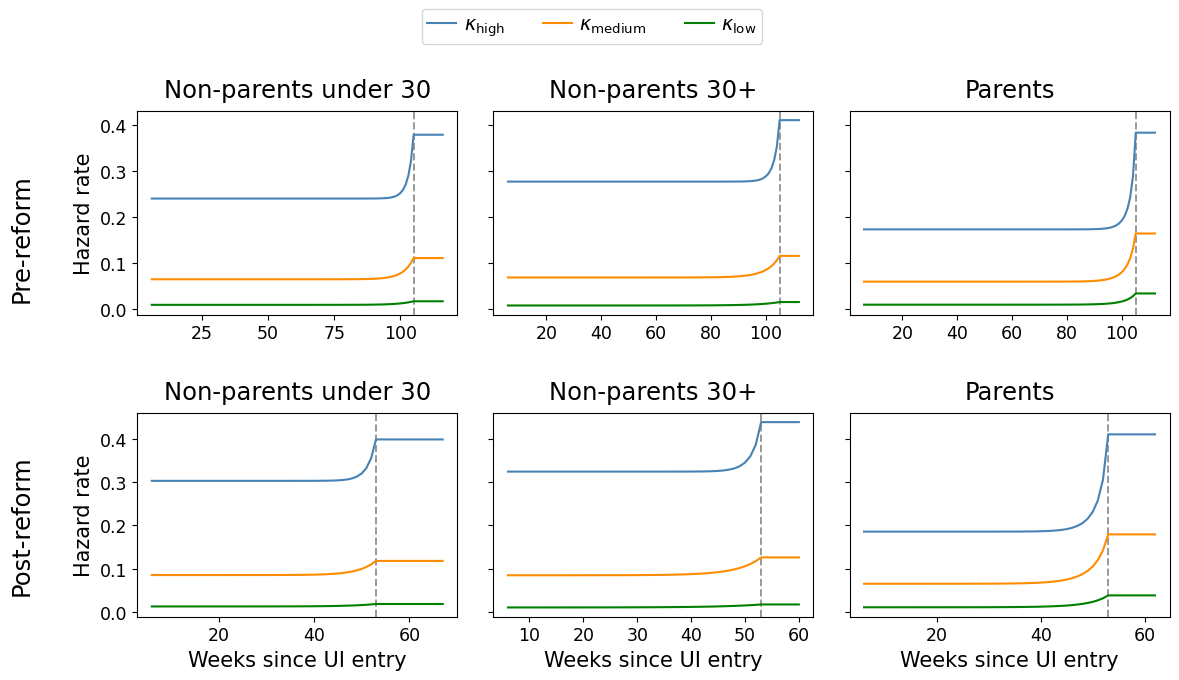

In [28]:

# ---------------------------------------------------------------------------
# Typography
# Scaled by 1 / 0.8 so the text matches figures inserted at width=\linewidth.
# ---------------------------------------------------------------------------
mpl.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 17.5,
    "axes.labelsize": 15,
    "xtick.labelsize": 12.5,
    "ytick.labelsize": 12.5,
    "legend.fontsize": 13.75,
})

TITLE_SIZE = 17.5
LABEL_SIZE = 15
TICK_SIZE = 12.5
ROW_LABEL_SIZE = 17.5
LEGEND_SIZE = 13.75


# ── Simulate ──────────────────────────────────────────────────────────────────
for subgroups in demo_groups:
    pre, post = subgroups
    model = individual_models[pre]
    sim_hr_prepost(model.par, model.sol, [subgroups])


# ── Collect ───────────────────────────────────────────────────────────────────
m1, m2, m3 = individual_models["pre1"], individual_models["pre2"], individual_models["pre3"]

ms = m1.par.moments_start
x_pre_u_trim   = np.arange(ms, len(m1.data.pre1.moments))
x_post_u_trim  = np.arange(ms, len(m1.data.post1.moments))
x_pre_o_trim   = np.arange(ms, len(m2.data.pre2.moments))
x_post_o_trim  = np.arange(ms, len(m2.data.post2.moments))
x_pre_par_trim = np.arange(ms, len(m3.data.pre3.moments))
x_post_par_trim= np.arange(ms, len(m3.data.post3.moments))

# ── Plot settings ─────────────────────────────────────────────────────────────
type_colors  = ["steelblue", "darkorange", "green"]
type_labels  = [r"$\kappa_{\mathrm{high}}$", r"$\kappa_{\mathrm{medium}}$", r"$\kappa_{\mathrm{low}}$"]
subplot_titles = ["Non-parents under 30", "Non-parents 30+", "Parents"]
hazard_linewidth, reference_color, reference_linewidth = 1.5, "0.6", 1.4

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey="row")

row_configs = [
    (axes[0], [(m1,"pre1","pre1",x_pre_u_trim), (m2,"pre2","pre2",x_pre_o_trim), (m3,"pre3","pre3",x_pre_par_trim)], 105),
    (axes[1], [(m1,"pre1","post1",x_post_u_trim), (m2,"pre2","post2",x_post_o_trim), (m3,"pre3","post3",x_post_par_trim)], 53),
]

for row_axes, row_data, vline_x in row_configs:
    for ax, (m, pre, group, x_trim), title in zip(row_axes, row_data, subplot_titles + [None, None, None]):
        gpar, gsol = getattr(m.par, group), getattr(m.sol, group)
        for k in range(m.par.n_types):
            type_moments = gsol.s[k, :]
            ax.plot(x_trim, type_moments[x_trim], color=type_colors[k], linestyle="-", linewidth=hazard_linewidth, label=type_labels[k])
        ax.axvline(x=vline_x, color=reference_color, linestyle="--", linewidth=reference_linewidth, alpha=reference_alpha, zorder=0)
        ax.tick_params(axis="both", labelsize=TICK_SIZE)
        ax.grid(False)
        if title:
            ax.set_title(title, fontsize=TITLE_SIZE, fontweight="normal", pad=10)

# ── Axis labels ───────────────────────────────────────────────────────────────
axes[0, 0].set_ylabel("Hazard rate", fontsize=LABEL_SIZE)
axes[1, 0].set_ylabel("Hazard rate", fontsize=LABEL_SIZE)
for ax in axes[1]:
    ax.set_xlabel("Weeks since UI entry", fontsize=LABEL_SIZE)

# ── Row labels ────────────────────────────────────────────────────────────────
fig.text(0.025, 0.68, "Pre-reform",  rotation=90, va="center", ha="center", fontsize=ROW_LABEL_SIZE)
fig.text(0.025, 0.27, "Post-reform", rotation=90, va="center", ha="center", fontsize=ROW_LABEL_SIZE)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [Line2D([0], [0], color=c, linewidth=hazard_linewidth, label=l) for c, l in zip(type_colors, type_labels)]
fig.legend(handles=legend_handles, loc="upper center", ncol=3, frameon=True, fontsize=LEGEND_SIZE,
           bbox_to_anchor=(0.5, 1.02), labelspacing=0.15, handlelength=1.5, handletextpad=0.4, borderpad=0.3)

# ── Layout and export ─────────────────────────────────────────────────────────
plt.tight_layout(rect=[0.05, 0.03, 1, 0.94], w_pad=1.5, h_pad=1.8)
#plt.savefig("cost_types_log_all.pdf", bbox_inches="tight")
plt.show()

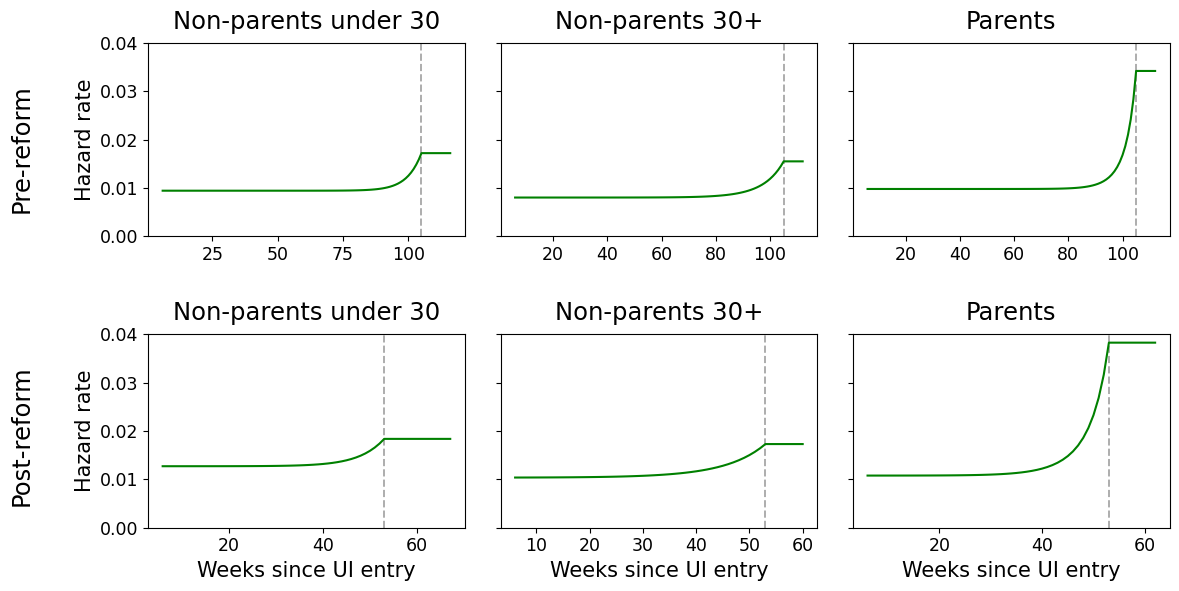

In [29]:

# ---------------------------------------------------------------------------
# Typography
# Scaled by 1 / 0.8 so the text matches figures inserted at width=\linewidth.
# ---------------------------------------------------------------------------
mpl.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 17.5,
    "axes.labelsize": 15,
    "xtick.labelsize": 12.5,
    "ytick.labelsize": 12.5,
    "legend.fontsize": 13.75,
})

TITLE_SIZE = 17.5
LABEL_SIZE = 15
TICK_SIZE = 12.5
ROW_LABEL_SIZE = 17.5
LEGEND_SIZE = 13.75

# ── Settings ──────────────────────────────────────────────────────────────────
k_low = 2
subplot_titles = ["Non-parents under 30", "Non-parents 30+", "Parents"]
line_color, line_width = "green", 1.5
reference_color, reference_linewidth, reference_alpha = "0.6", 1.4, 0.8

# ── Figure ────────────────────────────────────────────────────────────────────
fig_low, axes_low = plt.subplots(2, 3, figsize=(12, 7), sharey="row")

row_configs = [
    (axes_low[0], [(m1,"pre1",x_pre_u_trim), (m2,"pre2",x_pre_o_trim), (m3,"pre3",x_pre_par_trim)],   105),
    (axes_low[1], [(m1,"post1",x_post_u_trim), (m2,"post2",x_post_o_trim), (m3,"post3",x_post_par_trim)], 53),
]

for row_axes, row_data, vline_x in row_configs:
    for ax, (m, group, x_trim), title in zip(row_axes, row_data, subplot_titles + [None, None, None]):
        gpar, gsol = getattr(m.par, group), getattr(m.sol, group)
        ax.plot(x_trim, gsol.s[k_low, x_trim], color=line_color, linestyle="-", linewidth=line_width, label=r"$\kappa_{\mathrm{low}}$")
        ax.axvline(x=vline_x, color=reference_color, linestyle="--", linewidth=reference_linewidth, alpha=reference_alpha, zorder=0)
        ax.tick_params(axis="both", labelsize=TICK_SIZE)
        ax.grid(False)
        if title:
            ax.set_title(title, fontsize=TITLE_SIZE, fontweight="normal", pad=10)

# ── Y limits, axis labels ─────────────────────────────────────────────────────
for ax in axes_low.flat:
    ax.set_ylim(0, 0.04)

axes_low[0, 0].set_ylabel("Hazard rate", fontsize=LABEL_SIZE)
axes_low[1, 0].set_ylabel("Hazard rate", fontsize=LABEL_SIZE)
for ax in axes_low[1]:
    ax.set_xlabel("Weeks since UI entry", fontsize=LABEL_SIZE)
for ax in axes_low[:, 1:].flat:
    ax.tick_params(labelleft=False)

# ── Row labels ────────────────────────────────────────────────────────────────
fig_low.text(0.025, 0.68, "Pre-reform",  rotation=90, va="center", ha="center", fontsize=ROW_LABEL_SIZE)
fig_low.text(0.025, 0.27, "Post-reform", rotation=90, va="center", ha="center", fontsize=ROW_LABEL_SIZE)

# ── Layout and export ─────────────────────────────────────────────────────────
plt.tight_layout(rect=[0.05, 0.03, 1, 0.91], w_pad=1.5, h_pad=1.8)
#plt.savefig("cost_types_log_low.pdf", bbox_inches="tight")
plt.show()